## Define functions

In [1]:
import numpy as np
import pandas as pd
import os

# --- Load Data ---
def load_data(file_path):
    """
    Loads timestamped accelerometer data from a CSV file.

    Args:
        file_path (str): Path to the input data file.

    Returns:
        pd.DataFrame: DataFrame containing columns ['x', 'y', 'z', 'timestamp'].
    """
    return pd.read_csv(file_path, names=['x', 'y', 'z', 'timestamp'])

# --- Interpolation Method ---
def align_by_interpolation(ref_df, align_df):
    """
    Aligns align_df to ref_df's timestamps using linear interpolation.

    Args:
        ref_df (pd.DataFrame): Reference dataframe with target timestamps.
        align_df (pd.DataFrame): Dataframe to align using interpolation.

    Returns:
        Tuple[pd.DataFrame, pd.DataFrame]: (ref_df, interpolated_aligned_df)
    """
    interp_df = pd.DataFrame()
    interp_df['timestamp'] = ref_df['timestamp']
    interp_df['x'] = np.interp(ref_df['timestamp'], align_df['timestamp'], align_df['x'])
    interp_df['y'] = np.interp(ref_df['timestamp'], align_df['timestamp'], align_df['y'])
    interp_df['z'] = np.interp(ref_df['timestamp'], align_df['timestamp'], align_df['z'])
    interp_df = interp_df[['x', 'y', 'z', 'timestamp']]
    return ref_df, interp_df

# --- Save Aligned Data ---
def save_aligned_data(df_55, df_193, output_path):
    """
    Saves aligned data from two dataframes into a single CSV file in the order 55 then 193.

    Args:
        df_55 (pd.DataFrame): Aligned data from device 55.
        df_193 (pd.DataFrame): Aligned data from device 193.
        output_path (str): Path to save the output file.
    """
    aligned = pd.concat([df_55.add_suffix('_1'), df_193.add_suffix('_2')], axis=1)
    aligned.to_csv(output_path, index=False)
    print(f"Saved aligned data to {output_path}")

# --- Load, align and save ---
def load_align_save(distance):
    """
    Loads, aligns, and saves accelerometer data for multiple pairs of recordings,
    always saving in the order (55, 193) but aligning using the device with fewer samples.

    Args:
        distance (str): Distance label used in filenames (e.g., '50', '155').
    """
    for i in range(1, 6):
        df_55 = load_data(f'{distance}_{i}_55.txt')
        df_193 = load_data(f'{distance}_{i}_193.txt')

        # Prevent extrapolation by choosing the smaller one as reference
        if len(df_55) <= len(df_193):
            ref_df, aligned_df = align_by_interpolation(df_55, df_193)
        else:
            ref_df, aligned_df = align_by_interpolation(df_193, df_55)

        # Ensure df_55 is always saved as _1 and df_193 as _2
        if ref_df.equals(df_55):
            save_aligned_data(ref_df, aligned_df, f'aligned_{distance}_{i}.txt')
        else:
            save_aligned_data(aligned_df, ref_df, f'aligned_{distance}_{i}.txt')


def load_all_aligned_data_to_dict(file_prefixes):
    """
    Loads all aligned data files matching each prefix into a dictionary of DataFrames.
    
    Args:
        file_prefixes (List[str]): List of file name prefixes (e.g., ['263', 'static']).
    
    Returns:
        Dict[str, pd.DataFrame]: Dictionary of label -> DataFrame.
    """
    dfs = {}
    for prefix in file_prefixes:
        for i in range(1, 6):
            file_path = f'aligned_{prefix}_{i}.txt'
            if os.path.exists(file_path):
                df = pd.read_csv(file_path, names=[
                    'x1', 'y1', 'z1', 'timestamp1', 'x2', 'y2', 'z2', 'timestamp2'
                ], dtype=str)  # Read as string first to avoid DtypeWarning

                # Convert all columns to numeric safely
                for col in df.columns:
                    df[col] = pd.to_numeric(df[col], errors='coerce')

                # Drop any rows with NaNs if needed
                df = df.dropna().reset_index(drop=True)

                key = f"{prefix}_{i}"
                dfs[key] = df
            else:
                print(f"File not found: {file_path}")
    return dfs

In [ ]:
import numpy as np
import pandas as pd
import os
from scipy.signal import butter, filtfilt, correlate
import matplotlib.pyplot as plt

# --- Signal Processing Functions ---

def preamplify(data, gain_dB):
    gain = 10**(gain_dB / 20)
    return data * gain

def anti_alias_filter(data, cutoff_freq, Fs, order=4):
    nyq = 0.5 * Fs
    normal_cutoff = cutoff_freq / nyq
    b, a = butter(order, normal_cutoff, btype='lowpass')
    return filtfilt(b, a, data)

def bandpass_filter(signal, fs, lowcut=30, highcut=1200, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)

def compute_rms_noise(static_data_dict):
    rms_list = []
    for df in static_data_dict.values():
        a1 = np.sqrt(((df['x1']-16.25)/256)**2 + ((df['y1']+7.4)/256)**2 + ((df['z1']-252.8)/256)**2)
        a2 = np.sqrt(((df['x2']-21.3)/256)**2 + ((df['y2']+20.72)/256)**2 + ((df['z2']-188)/256)**2)
        rms_list.append(np.mean(np.sqrt(a1**2 + a2**2)))
    return np.mean(rms_list), np.std(rms_list)

def find_event(signal, threshold):
    energy = np.abs(signal)
    if np.max(energy) < threshold:
        return None
    return np.argmax(energy)

def extract_event_window(signal, event_index, window_size_samples):
    start = max(event_index - window_size_samples // 2, 0)
    end = min(event_index + window_size_samples // 2, len(signal))
    return signal[start:end]

def cross_correlate_signals(sig1, sig2, fs):
    corr = correlate(sig2, sig1, mode='full')
    lags = np.arange(-len(sig1) + 1, len(sig2)) / fs
    delay = lags[np.argmax(corr)]
    return corr, lags, delay

# --- Analysis Function ---

def analyze_with_sliding_window(data_dict, static_dict, Fs=3200, window_sec=1, slide_sec=0.2, gain_dB=20):
    pvc_speed = 2395
    sensor_distance = 3.5
    max_delay = sensor_distance / pvc_speed
    delays_by_file = {}

    noise_mean, noise_std = compute_rms_noise(static_dict)
    threshold = noise_mean + 5 * noise_std

    window_size = int(window_sec * Fs)
    slide_size = int(slide_sec * Fs)

    for label, df in data_dict.items():
        a1 = np.sqrt(((df['x1']-16.25)/256)**2 + ((df['y1']+7.4)/256)**2 + ((df['z1']-252.8)/256)**2)
        a2 = np.sqrt(((df['x2']-21.3)/256)**2 + ((df['y2']+20.72)/256)**2 + ((df['z2']-188)/256)**2)

        a1 = preamplify(a1, gain_dB)
        a2 = preamplify(a2, gain_dB)

        a1 = anti_alias_filter(a1, 1400, Fs)
        a2 = anti_alias_filter(a2, 1400, Fs)

        sig1_filt = bandpass_filter(a1, Fs)
        sig2_filt = bandpass_filter(a2, Fs)

        delays = []
        for start in range(0, len(sig1_filt) - window_size + 1, slide_size):
            win1 = sig1_filt[start:start + window_size]
            win2 = sig2_filt[start:start + window_size]

            idx1 = find_event(win1, threshold)
            idx2 = find_event(win2, threshold)

            if idx1 is None or idx2 is None:
                continue

            ev1 = extract_event_window(win1, idx1, window_size)
            ev2 = extract_event_window(win2, idx2, window_size)

            corr, lags, delay = cross_correlate_signals(ev1, ev2, Fs)

            if abs(delay) > max_delay:
                continue

            delays.append(delay)

            plt.figure(figsize=(8, 4))
            plt.plot(lags, corr)
            plt.axvline(delay, color='r', linestyle='--', label=f'Delay = {delay:.4f}s')
            plt.title(f'{label} - Cross-correlation')
            plt.xlabel('Lag (s)')
            plt.ylabel('Correlation')
            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            plt.show()

        if delays:
            avg_delay = np.mean(delays)
            est_loc = sensor_distance / 2 - pvc_speed * avg_delay
            delays_by_file[label] = (avg_delay, est_loc)
            print(f"[{label}] Avg Delay: {avg_delay:.6f}s -> Estimated Location: {est_loc:.2f}m")
        else:
            print(f"[{label}] No valid events detected.")
    
    return delays_by_file


## Import and Align data

In [31]:
import pandas as pd

load_align_save(263)
load_align_save(155)
# load_align_save(50)
# load_align_save('static')

Saved aligned data to aligned_263_1.txt
Saved aligned data to aligned_263_2.txt
Saved aligned data to aligned_263_3.txt
Saved aligned data to aligned_263_4.txt
Saved aligned data to aligned_263_5.txt
Saved aligned data to aligned_155_1.txt
Saved aligned data to aligned_155_2.txt
Saved aligned data to aligned_155_3.txt
Saved aligned data to aligned_155_4.txt
Saved aligned data to aligned_155_5.txt


## Analyze data and Plotting

In [3]:
file_prefixes = ['263', '155', '50']
static_prefixes = ['static']

data_dict = load_all_aligned_data_to_dict(file_prefixes)
static_dict = load_all_aligned_data_to_dict(static_prefixes)

[263_1] No valid events detected.
[263_2] No valid events detected.
[263_3] No valid events detected.
[263_4] No valid events detected.


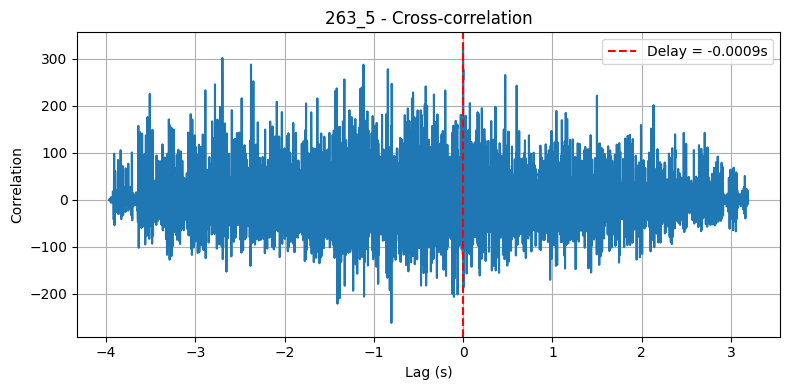

[263_5] Avg Delay: -0.000937s -> Estimated Location: 4.00m
[155_1] No valid events detected.
[155_2] No valid events detected.
[155_3] No valid events detected.
[155_4] No valid events detected.
[155_5] No valid events detected.
[50_1] No valid events detected.


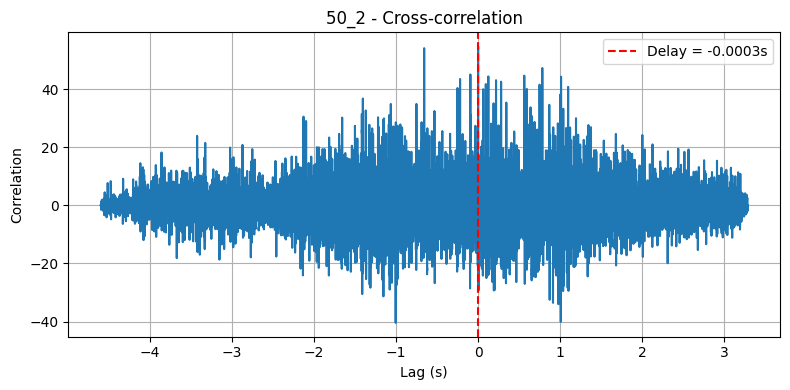

[50_2] Avg Delay: -0.000313s -> Estimated Location: 2.50m
[50_3] No valid events detected.
[50_4] No valid events detected.
[50_5] No valid events detected.


In [26]:
results = analyze_with_sliding_window(data_dict, static_dict)